# Wybrane Zagadnienia Sztucznej Inteligencji — Zestaw Zaliczeniowy

**WSEI Kraków · semestr letni 2026 · prowadzący: Michał Madejski**

---

## Filozofia tego zestawu

Sześć laboratoriów przeprowadziło Cię od **najprostszego klasyfikatora liniowego** (perceptron) do **sieci pamiętających kontekst** (LSTM). Ten zestaw zaliczeniowy zmusza Cię do **świadomego użycia tych architektur** — każdą na świeżym datasecie z Hugging Face, z porównaniem przed/po.

**Datasety z HF Hub:**
- `sklearn iris` (lokalny w sklearn — używamy do wprowadzenia perceptronu)
- [`zalando-datasets/fashion_mnist`](https://huggingface.co/datasets/zalando-datasets/fashion_mnist) — 70k obrazów 28×28 ubrań (główny image dataset)
- [`uoft-cs/cifar10`](https://huggingface.co/datasets/uoft-cs/cifar10) — 60k obrazów 32×32 RGB
- [`dair-ai/emotion`](https://huggingface.co/datasets/dair-ai/emotion) — 20k tweetów z 6 emocjami

**Reguły:**
1. Każdy lab ma blok: **Teoria → Przykład rozwiązany → Zadanie samodzielne**.
2. Zadania samodzielne **rozszerzają** przykład — ta sama architektura, trudniejszy problem.
3. Cały notebook ma być **uruchamialny od góry do dołu**. Brak ręcznych downloadów.
4. Każde rozwiązanie kończy się **wnioskiem z 2-3 zdań** w komórce Markdown.

**Ocenianie:**
- 50% — poprawność (czy model się uczy, accuracy > baseline)
- 30% — jakość kodu i wizualizacji
- 20% — **insight**: dlaczego twój model radzi sobie tak a nie inaczej? Co byłoby gdybyś zmienił X?

**Acceptance criteria:** każde zadanie ma komentarz z assertem typu "expected: val_acc > 0.85". Te asserty mówią Ci czy implementacja działa.

---

## Mapa zestawu

| # | Lab | Architektura | Dataset | Twoje zadanie | Czas CPU |
|---|-----|--------------|---------|---------------|----------|
| 1 | Perceptron 2D | iris | 2 klasy → wizualizacja granicy | Fashion-MNIST 2 łatwe klasy + wizualizacja wag | < 1 min |
| 2 | Perceptron na obrazach | Fashion-MNIST (T-shirt vs Sneaker) | + porównanie z LogReg | Fashion-MNIST trudna para (Pullover vs Coat) + confusion matrix | < 1 min |
| 3 | MLP + backprop (numpy) | XOR (sigmoid, binarny) | sieć od zera | MLP3 (softmax, 3-class) numpy na Fashion-MNIST | ~3 min |
| 4 | CNN (TensorFlow) | Fashion-MNIST | prosta CNN, 5 epok | CIFAR-10 — porównanie 2 architektur | ~5 min |
| 5 | Augmentacja danych | CIFAR-10 (z aug vs bez) | RandomFlip/Rotation/Zoom | **mini grid** 2×2×2 + 2-fold CV na Fashion-MNIST | ~15 min |
| 6 | RNN/LSTM | sinusoida z szumem | LSTM od zera | LSTM na klasyfikacji emocji w tekście (`dair-ai/emotion`) | ~3 min |

---

## Setup

In [4]:
import os, sys, time, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BAR"] = "1"

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(42)
np.random.seed(42)

WORKDIR = Path("./_workspace")
WORKDIR.mkdir(exist_ok=True)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")
print(f"NumPy: {np.__version__}")

TensorFlow: 2.15.1
GPU: False
NumPy: 1.26.4


---

# Lab 1 — Perceptron (klasyfikator liniowy)

## Teoria w trzech zdaniach

**Perceptron** to najprostsza sieć neuronowa: kombinacja liniowa wejść + funkcja progowa. Uczy się przesuwając **hiperpłaszczyznę decyzyjną** w przestrzeni cech tak, by oddzielała klasy.

**Ograniczenie:** działa tylko gdy dane są **liniowo separowalne**. XOR nie jest — i dlatego potrzebujemy warstw ukrytych (Lab 3).

**Reguła aktualizacji:** `w ← w + lr · (y - ŷ) · x`. Klasycznie: jeśli zgadnie dobrze, nie zmienia wag; jeśli źle, przesuwa wagi w stronę poprawy.

## Przykład rozwiązany: iris (2D), wizualizacja granicy decyzji

Test accuracy: 1.000
Wagi: w=[-0.31  0.59], bias=-0.10


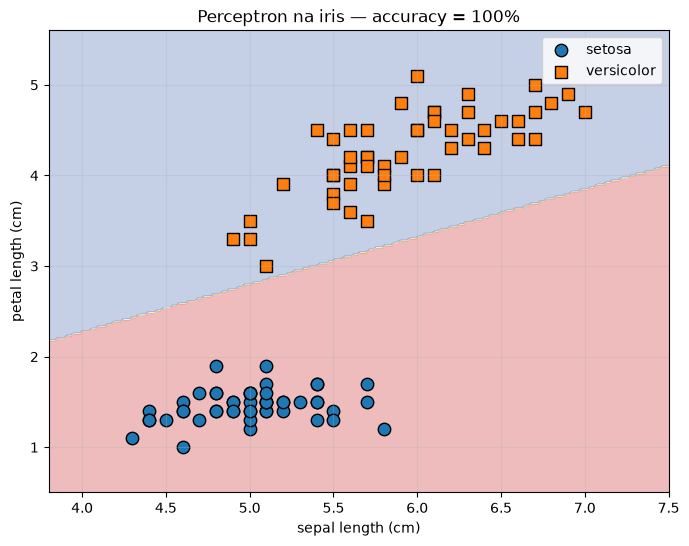


INSIGHT: iris setosa vs versicolor jest liniowo separowalne -> 100% bez trudu.


In [5]:
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split

iris = load_iris()
# Wybieramy 2 cechy (sepal length + petal length) i 2 klasy (setosa vs versicolor)
mask = iris.target < 2
X = iris.data[mask][:, [0, 2]]  # 2 cechy do wizualizacji
y = iris.target[mask]
feat_names = [iris.feature_names[0], iris.feature_names[2]]
class_names = [iris.target_names[0], iris.target_names[1]]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=42)

clf = Perceptron(max_iter=100, eta0=0.1, random_state=42)
clf.fit(X_tr, y_tr)
acc = clf.score(X_te, y_te)
print(f"Test accuracy: {acc:.3f}")
print(f"Wagi: w={clf.coef_[0]}, bias={clf.intercept_[0]:.2f}")

# Wizualizacja granicy
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlBu")
for cls, marker, label in [(0, "o", class_names[0]), (1, "s", class_names[1])]:
    plt.scatter(X[y == cls, 0], X[y == cls, 1], marker=marker, s=80,
                edgecolor="k", label=label)
plt.xlabel(feat_names[0]); plt.ylabel(feat_names[1])
plt.title(f"Perceptron na iris — accuracy = {acc:.0%}")
plt.legend(); plt.grid(alpha=0.3)
plt.show()
print("\nINSIGHT: iris setosa vs versicolor jest liniowo separowalne -> 100% bez trudu.")

## Zadanie 1.1 — Perceptron na Fashion-MNIST (2 klasy)

**Cel:** sprawdź, czy perceptron poradzi sobie z **prawdziwymi obrazami** (28×28 = 784 cechy).

**Wymagania:**

1. Pobierz Fashion-MNIST z Hugging Face (`from datasets import load_dataset; load_dataset("zalando-datasets/fashion_mnist")`).
2. Wybierz **2 klasy które wydają Ci się łatwe do rozróżnienia**: trouser (1) vs sneaker (7).
3. Spłaszcz obrazy do wektora 784 cech, znormalizuj (`/ 255.0`).
4. Wytrenuj `sklearn.linear_model.Perceptron` (max_iter=50).
5. Ewaluuj na test set: accuracy + confusion matrix.
6. **Wizualizuj wagi** jako obraz 28×28 (`clf.coef_.reshape(28, 28)`) — zobaczysz "szablon" jaki perceptron znalazł.
7. **Bonus:** wyświetl 5 obrazów, które perceptron sklasyfikował błędnie. Co je łączy?

**Wskazówka:** `images = np.array([np.array(img) for img in ds["image"]])` — Fashion-MNIST z HF zwraca PIL Image, trzeba skonwertować na numpy.

Skuteczność: 0.9995
Macierz pomyłek:
 [[ 999    1]
 [   0 1000]]


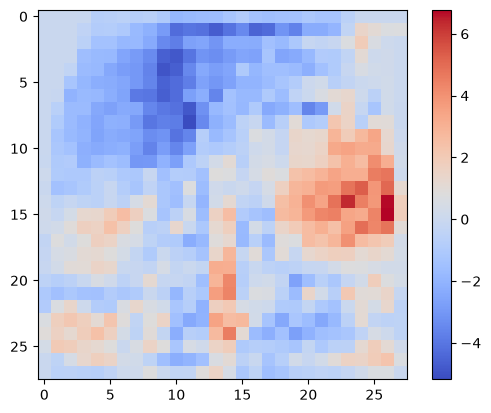

Znaleziono 1 błędów


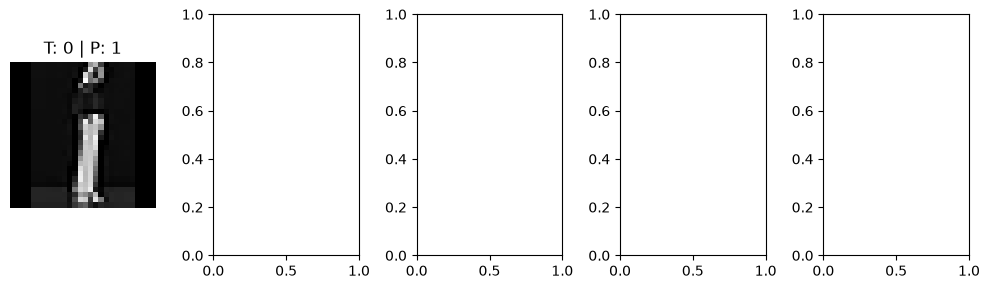

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix

fmnist = load_dataset("zalando-datasets/fashion_mnist")

train_imgs = np.array([np.array(pic) for pic in fmnist["train"]["image"]])
train_lbls = np.array(fmnist["train"]["label"])
test_imgs = np.array([np.array(pic) for pic in fmnist["test"]["image"]])
test_lbls = np.array(fmnist["test"]["label"])

mask_tr = np.isin(train_lbls, [1, 7])
mask_te = np.isin(test_lbls, [1, 7])

X_tr = train_imgs[mask_tr].reshape(-1, 28 * 28) / 255.0
y_tr = (train_lbls[mask_tr] == 7).astype(int)

test_imgs_filt = test_imgs[mask_te]
X_te = test_imgs_filt.reshape(-1, 28 * 28) / 255.0
y_te = (test_lbls[mask_te] == 7).astype(int)

model = Perceptron(max_iter=50, random_state=42)
model.fit(X_tr, y_tr)

preds = model.predict(X_te)

print(f"Skuteczność: {accuracy_score(y_te, preds):.4f}")
print("Macierz pomyłek:\n", confusion_matrix(y_te, preds))

plt.figure("Wizualizacja Wag")
plt.imshow(model.coef_.reshape(28, 28), cmap="coolwarm")
plt.colorbar()
plt.show()

bad_idx = np.where(y_te != preds)[0]
print(f"Znaleziono {len(bad_idx)} błędów")

if len(bad_idx) > 0:
    fig, axes = plt.subplots(1, 5, figsize=(10, 3))
    for i, ax in enumerate(axes):
        if i < len(bad_idx):
            idx = bad_idx[i]
            ax.imshow(test_imgs_filt[idx], cmap="gray")
            ax.set_title(f"T: {y_te[idx]} | P: {preds[idx]}")
            ax.axis("off")
    plt.tight_layout()
    plt.show()

---

# Lab 2 — Perceptron na obrazach

## Teoria w trzech zdaniach

**Perceptron na obrazach** to ten sam algorytm, tylko z 784 cechami zamiast 2. Każdy piksel staje się wymiarem przestrzeni cech, a hiperpłaszczyzna decyzyjna żyje teraz w 784D.

**Kluczowa intuicja:** wagi `w_i` mówią, **jak ważny jest piksel i**. Wizualizacja `w.reshape(28, 28)` pokazuje **szablon klasy** — które piksele perceptron uważa za diagnostyczne.

**Ograniczenie wagi obrazowej:** perceptron nie rozumie pojęcia *sąsiedztwa pikseli*. Dla niego piksel (5, 10) i (20, 25) są tak samo niezależne. To dlatego CNN są lepsze — uwzględniają lokalność.

## Przykład rozwiązany: Fashion-MNIST shirt vs sneaker

Train: (2000, 784), Test: (500, 784)
Perceptron       -> train acc: 1.000, test acc: 1.000
LogReg           -> train acc: 1.000, test acc: 1.000


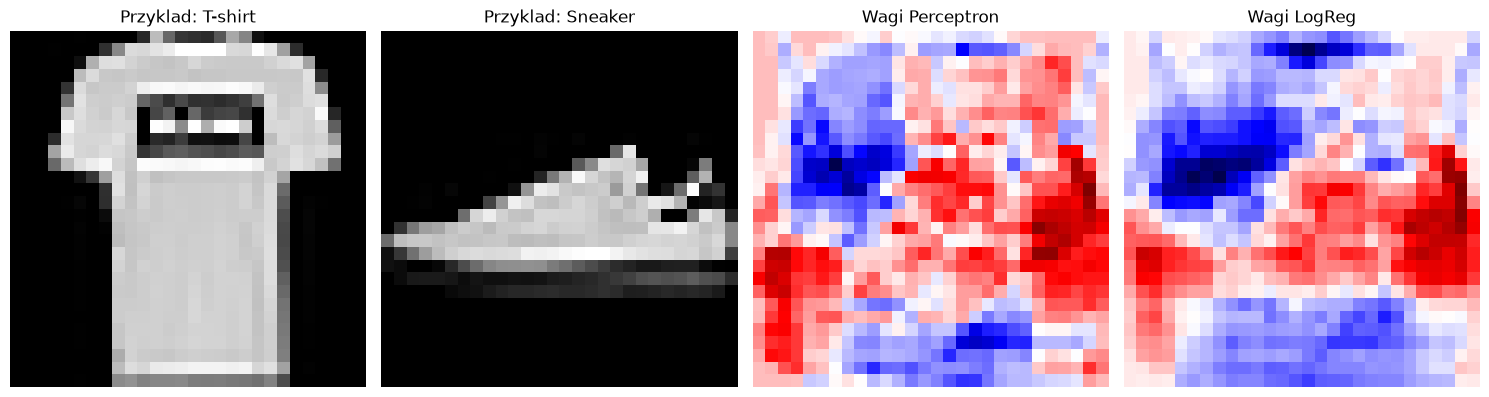


INSIGHT: T-shirt vs Sneaker = bardzo rozne ksztalty -> oba modele ~100%.
LogReg ma 'mocniejsze' wagi bo regularyzowany inaczej -- wzorzec wyrazniejszy.


In [7]:
# Wczytaj Fashion-MNIST raz, dla pozniejszego ponownego uzycia
fashion = load_dataset("zalando-datasets/fashion_mnist")
FASHION_NAMES = ["T-shirt", "Trouser", "Pullover", "Dress", "Coat",
                 "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

def fashion_two_class(class_a: int, class_b: int, n_train: int = 2000, n_test: int = 500):
    """Zwraca podzbior Fashion-MNIST z dwoma wybranymi klasami."""
    def extract(split, n):
        ds = fashion[split]
        labels = np.array(ds["label"])
        mask = np.isin(labels, [class_a, class_b])
        idx = np.where(mask)[0][:n]
        imgs = np.array([np.array(ds[i]["image"]) for i in idx], dtype=np.float32) / 255.0
        labs = (labels[idx] == class_b).astype(int)  # binaryzacja: a=0, b=1
        return imgs.reshape(len(idx), -1), labs
    return extract("train", n_train), extract("test", n_test)

(X_tr, y_tr), (X_te, y_te) = fashion_two_class(0, 7)  # T-shirt vs Sneaker
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

clf = Perceptron(max_iter=50, eta0=0.01, random_state=42)
clf.fit(X_tr, y_tr)
acc_train = clf.score(X_tr, y_tr)
acc_test = clf.score(X_te, y_te)
print(f"Perceptron       -> train acc: {acc_train:.3f}, test acc: {acc_test:.3f}")

# Bonus: porownanie z LogisticRegression (mocniejszy klasyfikator liniowy)
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=200, random_state=42)
lr.fit(X_tr, y_tr)
print(f"LogReg           -> train acc: {lr.score(X_tr, y_tr):.3f}, test acc: {lr.score(X_te, y_te):.3f}")

# Wizualizacja: oryginaly + wagi obu modeli
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(X_tr[0].reshape(28, 28), cmap="gray")
axes[0].set_title(f"Przyklad: {FASHION_NAMES[0]}")
axes[0].axis("off")
axes[1].imshow(X_tr[np.where(y_tr==1)[0][0]].reshape(28, 28), cmap="gray")
axes[1].set_title(f"Przyklad: {FASHION_NAMES[7]}")
axes[1].axis("off")
axes[2].imshow(clf.coef_.reshape(28, 28), cmap="seismic")
axes[2].set_title(f"Wagi Perceptron")
axes[2].axis("off")
axes[3].imshow(lr.coef_.reshape(28, 28), cmap="seismic")
axes[3].set_title(f"Wagi LogReg")
axes[3].axis("off")
plt.tight_layout()
plt.show()

print("\nINSIGHT: T-shirt vs Sneaker = bardzo rozne ksztalty -> oba modele ~100%.")
print("LogReg ma 'mocniejsze' wagi bo regularyzowany inaczej -- wzorzec wyrazniejszy.")

## Zadanie 2.1 — Trudna para Fashion-MNIST

**Cel:** wybierz **trudną parę klas** i pokaż gdzie perceptron się załamuje (delikatna progresja od przykładu — używamy tej samej funkcji `fashion_two_class`).

**Wymagania:**

1. Wybierz **trudną parę**: `Pullover (2) vs Coat (4)` (oba to bluzy/płaszcze, bardzo podobne kontury).
2. Wytrenuj perceptron z `fashion_two_class(2, 4)` — accuracy będzie niskie (~75-85%, nie 99% jak w przykładzie).
3. Narysuj **confusion matrix** jako heatmap (`plt.imshow` lub `seaborn.heatmap`).
4. Zwizualizuj **5 najbardziej pewnych błędów** — te z największym `|clf.decision_function(x)|` przy złej klasie.
5. **Wniosek (1 komórka Markdown):** dlaczego ta para jest trudna? Czy to wina perceptronu, czy danych?

Perceptron Accuracy: 0.8540
Perceptron Confusion Matrix:
 [[843 157]
 [135 865]]
Logistic Regression Accuracy: 0.8505


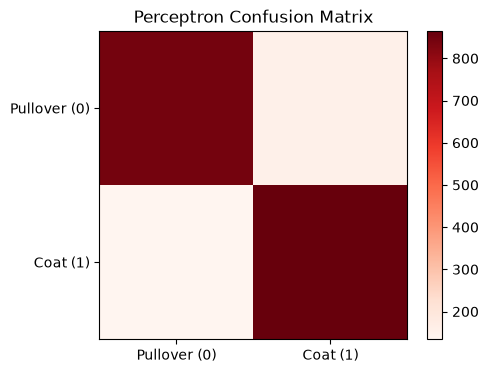

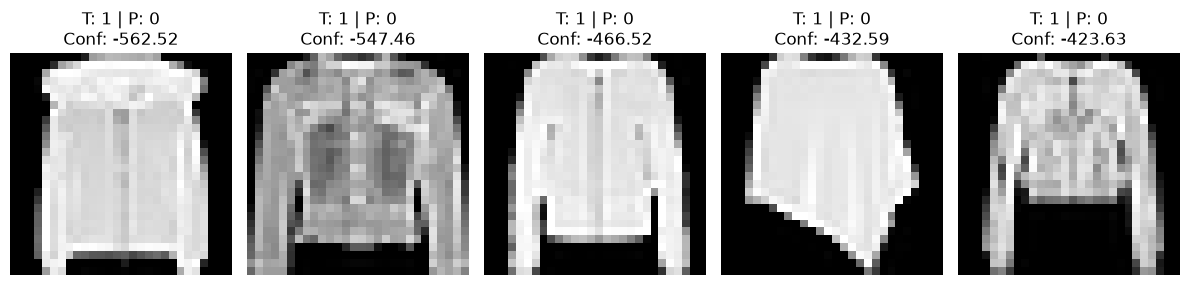

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix

fmnist_data = load_dataset("zalando-datasets/fashion_mnist")

img_tr = np.array([np.array(x) for x in fmnist_data["train"]["image"]])
lbl_tr = np.array(fmnist_data["train"]["label"])
img_te = np.array([np.array(x) for x in fmnist_data["test"]["image"]])
lbl_te = np.array(fmnist_data["test"]["label"])

c1, c2 = 2, 4

mask_tr = np.isin(lbl_tr, [c1, c2])
mask_te = np.isin(lbl_te, [c1, c2])

X_tr_sub = img_tr[mask_tr].reshape(mask_tr.sum(), 28 * 28) / 255.0
y_tr_sub = (lbl_tr[mask_tr] == c2).astype(int)

img_te_sub = img_te[mask_te]
X_te_sub = img_te_sub.reshape(mask_te.sum(), 28 * 28) / 255.0
y_te_sub = (lbl_te[mask_te] == c2).astype(int)

perc_model = Perceptron(max_iter=50, random_state=42)
perc_model.fit(X_tr_sub, y_tr_sub)
preds_perc = perc_model.predict(X_te_sub)

print(f"Perceptron Accuracy: {accuracy_score(y_te_sub, preds_perc):.4f}")
c_matrix = confusion_matrix(y_te_sub, preds_perc)
print("Perceptron Confusion Matrix:\n", c_matrix)

log_reg = LogisticRegression(max_iter=100, random_state=42)
log_reg.fit(X_tr_sub, y_tr_sub)
preds_lr = log_reg.predict(X_te_sub)
print(f"Logistic Regression Accuracy: {accuracy_score(y_te_sub, preds_lr):.4f}")

fig, ax = plt.subplots(figsize=(5, 4))
cax = ax.imshow(c_matrix, cmap="Reds")
ax.set_title("Perceptron Confusion Matrix")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Pullover (0)", "Coat (1)"])
ax.set_yticklabels(["Pullover (0)", "Coat (1)"])
fig.colorbar(cax)
plt.show()

decisions = perc_model.decision_function(X_te_sub)
bad_preds = (y_te_sub != preds_perc)
bad_idx = np.where(bad_preds)[0]

conf_scores = np.abs(decisions[bad_idx])
sorted_err_idx = bad_idx[np.argsort(-conf_scores)][:5]

fig2, axes = plt.subplots(1, 5, figsize=(12, 3))
for idx_plot, real_idx in enumerate(sorted_err_idx):
    axes[idx_plot].imshow(img_te_sub[real_idx], cmap="gray")
    axes[idx_plot].set_title(f"T: {y_te_sub[real_idx]} | P: {preds_perc[real_idx]}\nConf: {decisions[real_idx]:.2f}")
    axes[idx_plot].axis("off")

plt.tight_layout()
plt.show()

---

# Lab 3 — MLP + Backpropagation

## Teoria w trzech zdaniach

**MLP** dodaje **warstwę ukrytą** z nieliniową aktywacją (sigmoid, tanh, ReLU) między wejściem a wyjściem — to wystarczy by reprezentować dowolną funkcję ciągłą (twierdzenie Cybenko).

**Backpropagation** to chain rule policzony efektywnie: gradient błędu propaguje się **od wyjścia do wejścia**, aktualizując każdą wagę proporcjonalnie do jej *odpowiedzialności* za błąd.

**Pamiętaj:** forward pass to mnożenia macierzy + aktywacja. Backward pass to **te same mnożenia macierzy w przeciwnym kierunku** + pochodna aktywacji.

## Przykład rozwiązany: XOR z czystego numpy

XOR ground truth: [0. 1. 1. 0.]
MLP predictions:   [0.    0.998 0.998 0.003]
Klasyfikacja po threshold 0.5: [0 1 1 0]


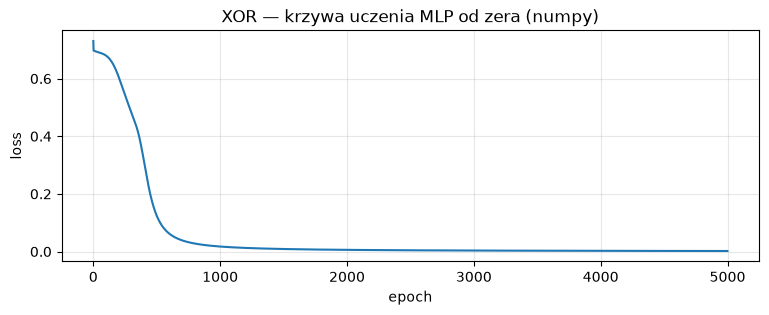

In [9]:
def sigmoid(z): return 1 / (1 + np.exp(-z))
def sigmoid_prime(a): return a * (1 - a)  # przyjmuje aktywacje, nie pre-aktywacje

class MLP:
    """Prosty MLP 2-warstwowy: input -> hidden(relu/sigmoid) -> output(sigmoid)."""
    def __init__(self, n_in, n_hidden, n_out, lr=0.1, seed=42):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2/n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr
    
    def forward(self, X):
        self.X = X
        self.a1 = sigmoid(X @ self.W1 + self.b1)
        self.a2 = sigmoid(self.a1 @ self.W2 + self.b2)
        return self.a2
    
    def backward(self, y):
        m = y.shape[0]
        # output layer
        dZ2 = (self.a2 - y)
        dW2 = self.a1.T @ dZ2 / m
        db2 = dZ2.mean(axis=0, keepdims=True)
        # hidden layer
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * sigmoid_prime(self.a1)
        dW1 = self.X.T @ dZ1 / m
        db1 = dZ1.mean(axis=0, keepdims=True)
        # update
        self.W2 -= self.lr * dW2; self.b2 -= self.lr * db2
        self.W1 -= self.lr * dW1; self.b1 -= self.lr * db1
    
    def train(self, X, y, epochs=5000):
        losses = []
        for _ in range(epochs):
            out = self.forward(X)
            loss = -np.mean(y * np.log(out + 1e-9) + (1-y) * np.log(1-out + 1e-9))
            losses.append(loss)
            self.backward(y)
        return losses

# XOR
X_xor = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_xor = np.array([[0],[1],[1],[0]], dtype=float)

mlp = MLP(n_in=2, n_hidden=4, n_out=1, lr=1.0)
losses = mlp.train(X_xor, y_xor, epochs=5000)

pred = mlp.forward(X_xor)
print("XOR ground truth:", y_xor.ravel())
print("MLP predictions:  ", np.round(pred.ravel(), 3))
print("Klasyfikacja po threshold 0.5:", (pred.ravel() > 0.5).astype(int))

plt.figure(figsize=(9, 3))
plt.plot(losses); plt.xlabel("epoch"); plt.ylabel("loss")
plt.title("XOR — krzywa uczenia MLP od zera (numpy)")
plt.grid(alpha=0.3)
plt.show()

## Zadanie 3.1 — MLP numpy dla Fashion-MNIST (3 klasy)

**Cel:** wytrenuj **trzywarstwowy MLP od zera w numpy** (bez TensorFlow!) na 3-klasowym problemie obrazowym.

**Wymagania:**

1. Rozszerz klasę `MLP` powyżej o **3 klasy wyjściowe** z softmax + cross-entropy.
2. Wybierz 3 klasy Fashion-MNIST (np. T-shirt, Trouser, Bag = 0, 1, 8).
3. Spłaszcz obrazy do 784, znormalizuj.
4. Trenuj **mini-batch** SGD (batch_size = 64), 30 epok.
5. Pokaż krzywą uczenia (loss + accuracy per epoch) na train i test.
6. Porównaj wynikowe accuracy z `sklearn.neural_network.MLPClassifier(hidden_layer_sizes=(64,))`.
7. **Wniosek:** ile epok i jaki LR działają najlepiej? Co się dzieje gdy `n_hidden = 4` vs `n_hidden = 256`?

**Wskazówka softmax:**
```python
def softmax(z):
    e = np.exp(z - z.max(axis=1, keepdims=True))  # numeryczna stabilnosc
    return e / e.sum(axis=1, keepdims=True)
```

Końcowe Accuracy Numpy MLP (Test): 0.9753
Końcowe Accuracy Sklearn MLP (Test): 0.6303


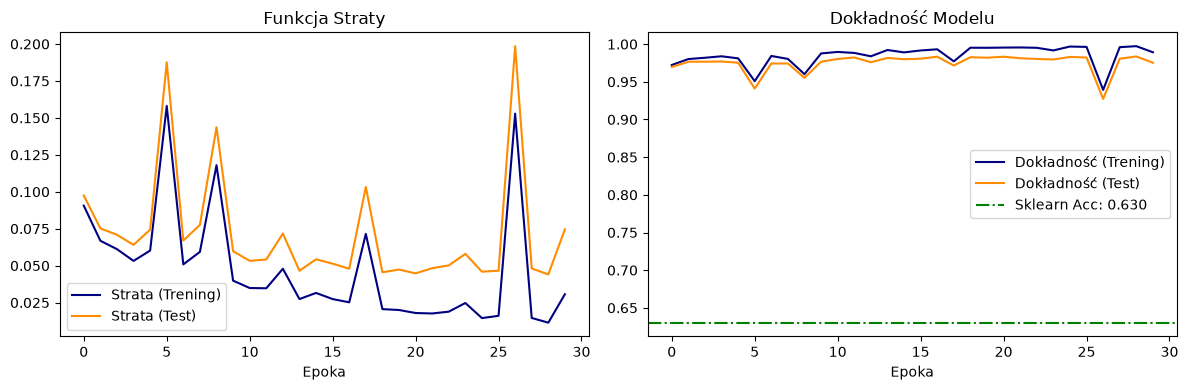

In [10]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier

def softmax(z):
    """Numerycznie stabilna softmax."""
    e = np.exp(z - z.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def relu(z): 
    return np.maximum(0, z)

def relu_prime(z): 
    return (z > 0).astype(float)

class MLP3:
    def __init__(self, n_in: int = 784, n_hidden: int = 64, n_out: int = 3,
                 lr: float = 0.01, seed: int = 42):
        rng = np.random.RandomState(seed)
        self.W1 = rng.randn(n_in, n_hidden) * np.sqrt(2/n_in)
        self.b1 = np.zeros((1, n_hidden))
        self.W2 = rng.randn(n_hidden, n_out) * np.sqrt(2/n_hidden)
        self.b2 = np.zeros((1, n_out))
        self.lr = lr

    def forward(self, X):
        self.X = X
        self.Z1 = X @ self.W1 + self.b1
        self.A1 = relu(self.Z1)
        self.Z2 = self.A1 @ self.W2 + self.b2
        self.A2 = softmax(self.Z2)
        return self.A2

    def backward(self, y_onehot):
        m_samples = y_onehot.shape[0]
        dz2 = (self.A2 - y_onehot) / m_samples
        dw2 = self.A1.T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)
        da1 = dz2 @ self.W2.T
        dz1 = da1 * relu_prime(self.Z1)
        dw1 = self.X.T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)
        self.W1 -= self.lr * dw1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dw2
        self.b2 -= self.lr * db2

    def train_minibatch(self, X, y_onehot, X_val, y_val_onehot, epochs=30, batch_size=64):
        history = {"loss": [], "acc": [], "val_loss": [], "val_acc": []}
        n = len(X)
        for ep in range(epochs):
            perm = np.random.permutation(n)
            for i in range(0, n, batch_size):
                idx = perm[i:i+batch_size]
                self.forward(X[idx])
                self.backward(y_onehot[idx])
            
            out_tr = self.forward(X)
            history["loss"].append(-np.mean(np.sum(y_onehot * np.log(out_tr + 1e-9), axis=1)))
            history["acc"].append((out_tr.argmax(axis=1) == y_onehot.argmax(axis=1)).mean())
            
            out_val = self.forward(X_val)
            history["val_loss"].append(-np.mean(np.sum(y_val_onehot * np.log(out_val + 1e-9), axis=1)))
            history["val_acc"].append((out_val.argmax(axis=1) == y_val_onehot.argmax(axis=1)).mean())
        return history

dataset = load_dataset("zalando-datasets/fashion_mnist")
CLASSES = [0, 1, 8]

def prepare_data(split):
    imgs = np.array([np.array(p) for p in dataset[split]["image"]])
    lbls = np.array(dataset[split]["label"])
    
    valid_mask = np.isin(lbls, CLASSES)
    
    X_data = imgs[valid_mask].reshape(-1, 28 * 28) / 255.0
    
    mapping = {CLASSES[i]: i for i in range(len(CLASSES))}
    y_mapped = np.vectorize(mapping.get)(lbls[valid_mask])
    
    y_one_hot = np.zeros((y_mapped.size, len(CLASSES)))
    y_one_hot[np.arange(y_mapped.size), y_mapped] = 1.0
    
    return X_data, y_mapped, y_one_hot

tr_x, tr_y, tr_y_oh = prepare_data("train")
te_x, te_y, te_y_oh = prepare_data("test")

net = MLP3(784, 64, 3, lr=0.1, seed=42)
hist = net.train_minibatch(tr_x, tr_y_oh, te_x, te_y_oh, epochs=30, batch_size=64)

sk_mlp = MLPClassifier(
    hidden_layer_sizes=(64,),
    max_iter=30,
    batch_size=64,
    learning_rate_init=0.1,
    random_state=42,
)
sk_mlp.fit(tr_x, tr_y)
sk_acc = accuracy_score(te_y, sk_mlp.predict(te_x))

print(f"Końcowe Accuracy Numpy MLP (Test): {hist['val_acc'][-1]:.4f}")
print(f"Końcowe Accuracy Sklearn MLP (Test): {sk_acc:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist["loss"], label="Strata (Trening)", color="navy")
ax1.plot(hist["val_loss"], label="Strata (Test)", color="darkorange")
ax1.set_title("Funkcja Straty")
ax1.set_xlabel("Epoka")
ax1.legend()

ax2.plot(hist["acc"], label="Dokładność (Trening)", color="navy")
ax2.plot(hist["val_acc"], label="Dokładność (Test)", color="darkorange")
ax2.axhline(y=sk_acc, color="green", linestyle="-.", label=f"Sklearn Acc: {sk_acc:.3f}")
ax2.set_title("Dokładność Modelu")
ax2.set_xlabel("Epoka")
ax2.legend()

plt.tight_layout()
plt.show()

---

# Lab 4 — CNN w TensorFlow

## Teoria w trzech zdaniach

**Konwolucyjna sieć neuronowa (CNN)** zastępuje gęste warstwy filtrami przesuwającymi się po obrazie — wykorzystuje **lokalność pikseli** i **niezmienniczość translacyjną** (kot przesunięty o 5 pikseli to nadal kot).

**Typowy blok CNN:** `Conv → BatchNorm → ReLU → MaxPool → Dropout`. Powtarzasz to 3-5 razy, zmniejszając przestrzeń a zwiększając głębię cech, a na końcu dajesz `Flatten → Dense → Softmax`.

**Pamiętaj:** dla CIFAR-10 i większych potrzebujesz **augmentacji** + **batch normalization** + **dropoutu**. Bez tego sieć overfituje na 3-5 epokach.

## Przykład rozwiązany: prosta CNN na Fashion-MNIST

In [11]:
# Wczytaj Fashion-MNIST do tablic numpy (z HF datasets)
def fashion_full_split():
    train_imgs = np.array([np.array(img) for img in fashion["train"]["image"]], dtype=np.float32) / 255.0
    train_labs = np.array(fashion["train"]["label"])
    test_imgs = np.array([np.array(img) for img in fashion["test"]["image"]], dtype=np.float32) / 255.0
    test_labs = np.array(fashion["test"]["label"])
    return (train_imgs[..., None], train_labs), (test_imgs[..., None], test_labs)

# Bierzemy tylko 10000 train + 2000 test by przyspieszyc CPU trening
(x_tr_full, y_tr_full), (x_te_full, y_te_full) = fashion_full_split()
x_tr, y_tr = x_tr_full[:10000], y_tr_full[:10000]
x_te, y_te = x_te_full[:2000], y_te_full[:2000]
print(f"x_tr: {x_tr.shape}, y_tr: {y_tr.shape}")
print(f"x_te: {x_te.shape}, y_te: {y_te.shape}")

def small_cnn(input_shape, n_classes):
    return keras.Sequential([
        layers.Input(input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ])

tf.random.set_seed(42)
model = small_cnn((28, 28, 1), 10)
model.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
hist = model.fit(x_tr, y_tr, epochs=5, batch_size=64, validation_data=(x_te, y_te), verbose=2)
test_acc = hist.history["val_accuracy"][-1]
print(f"\nFinal test accuracy: {test_acc:.3f}")

x_tr: (10000, 28, 28, 1), y_tr: (10000,)
x_te: (2000, 28, 28, 1), y_te: (2000,)
Epoch 1/5
157/157 - 2s - loss: 0.6005 - accuracy: 0.7946 - val_loss: 2.7098 - val_accuracy: 0.2195 - 2s/epoch - 13ms/step
Epoch 2/5
157/157 - 2s - loss: 0.3632 - accuracy: 0.8660 - val_loss: 1.9334 - val_accuracy: 0.5020 - 2s/epoch - 12ms/step
Epoch 3/5
157/157 - 2s - loss: 0.2902 - accuracy: 0.8931 - val_loss: 0.6262 - val_accuracy: 0.7860 - 2s/epoch - 13ms/step
Epoch 4/5
157/157 - 2s - loss: 0.2556 - accuracy: 0.9038 - val_loss: 0.3721 - val_accuracy: 0.8735 - 2s/epoch - 13ms/step
Epoch 5/5
157/157 - 2s - loss: 0.2055 - accuracy: 0.9236 - val_loss: 0.3768 - val_accuracy: 0.8695 - 2s/epoch - 13ms/step

Final test accuracy: 0.869


## Zadanie 4.1 — CNN na CIFAR-10 (porównaj 2 architektury)

**Cel:** zbuduj **dwie architektury CNN** dla CIFAR-10 i porównaj je rzetelnie.

**Wymagania:**

1. Pobierz CIFAR-10 z HF (`load_dataset("uoft-cs/cifar10")`).
2. Użyj 10000 train + 2000 test (subset dla rozsądnego czasu treningu na CPU).
3. **Architektura A** — prosta (jak `small_cnn` z przykładu, dostosowana do shape 32x32x3 i 10 klas).
4. **Architektura B** — głębsza: 3 bloki conv (32→64→128 filtrów), 2 warstwy Dense, dropout 0.5.
5. Trenuj obie po 8 epok, mierz czas każdej. 
6. Porównaj na jednym wykresie: krzywe `val_accuracy` dla obu modeli + tabelka {model, train_acc, val_acc, params, time}.
7. **Wniosek:** czy głębsza sieć była zawsze lepsza? Kiedy się to opłaca?

Epoch 1/8
157/157 - 3s - loss: 1.8061 - accuracy: 0.3931 - val_loss: 8.1582 - val_accuracy: 0.1510 - 3s/epoch - 20ms/step
Epoch 2/8
157/157 - 3s - loss: 1.3277 - accuracy: 0.5295 - val_loss: 6.5840 - val_accuracy: 0.2015 - 3s/epoch - 17ms/step
Epoch 3/8
157/157 - 3s - loss: 1.1485 - accuracy: 0.5955 - val_loss: 2.2755 - val_accuracy: 0.3895 - 3s/epoch - 16ms/step
Epoch 4/8
157/157 - 3s - loss: 0.9766 - accuracy: 0.6497 - val_loss: 1.6391 - val_accuracy: 0.5100 - 3s/epoch - 16ms/step
Epoch 5/8
157/157 - 3s - loss: 0.8281 - accuracy: 0.7078 - val_loss: 1.4719 - val_accuracy: 0.5430 - 3s/epoch - 17ms/step
Epoch 6/8
157/157 - 3s - loss: 0.7074 - accuracy: 0.7505 - val_loss: 1.3065 - val_accuracy: 0.5705 - 3s/epoch - 17ms/step
Epoch 7/8
157/157 - 3s - loss: 0.5620 - accuracy: 0.8013 - val_loss: 1.2907 - val_accuracy: 0.6005 - 3s/epoch - 16ms/step
Epoch 8/8
157/157 - 3s - loss: 0.4580 - accuracy: 0.8438 - val_loss: 1.4656 - val_accuracy: 0.5770 - 3s/epoch - 17ms/step
Epoch 1/8
157/157 - 9s -

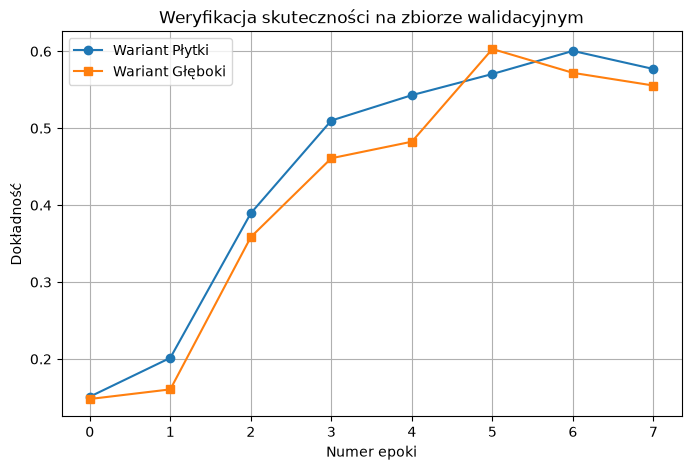

In [12]:
import time
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datasets import load_dataset

data_cifar = load_dataset("uoft-cs/cifar10")

x_train_norm = np.array([np.array(img) for img in data_cifar["train"]["img"][:10000]], dtype=np.float32) / 255.0
y_train_arr = np.array(data_cifar["train"]["label"][:10000], dtype=np.int32)

x_test_norm = np.array([np.array(img) for img in data_cifar["test"]["img"][:2000]], dtype=np.float32) / 255.0
y_test_arr = np.array(data_cifar["test"]["label"][:2000], dtype=np.int32)

def build_shallow_cnn(input_shape=(32, 32, 3), output_dim=10):
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(128, activation="relu"),
        layers.Dense(output_dim, activation="softmax"),
    ])

def build_deep_cnn(input_shape=(32, 32, 3), output_dim=10):
    return keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(128, activation="relu"),
        layers.Dense(output_dim, activation="softmax"),
    ])

tf.random.set_seed(42)

model_1 = build_shallow_cnn()
model_1.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
start_time_1 = time.time()
hist_1 = model_1.fit(x_train_norm, y_train_arr, epochs=8, batch_size=64, validation_data=(x_test_norm, y_test_arr), verbose=2)
elapsed_1 = time.time() - start_time_1

model_2 = build_deep_cnn()
model_2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
start_time_2 = time.time()
hist_2 = model_2.fit(x_train_norm, y_train_arr, epochs=8, batch_size=64, validation_data=(x_test_norm, y_test_arr), verbose=2)
elapsed_2 = time.time() - start_time_2

print(f"\n{'ARCHITEKTURA':<15} | {'TRAIN ACC':<10} | {'VAL ACC':<10} | {'PARAMY':<10} | {'CZAS'}")
print("-" * 70)
print(f"Płytka         | {hist_1.history['accuracy'][-1]:.4f}     | {hist_1.history['val_accuracy'][-1]:.4f}     | {model_1.count_params():<10} | {elapsed_1:.1f}s")
print(f"Głęboka        | {hist_2.history['accuracy'][-1]:.4f}     | {hist_2.history['val_accuracy'][-1]:.4f}     | {model_2.count_params():<10} | {elapsed_2:.1f}s")

plt.figure(figsize=(8, 5))
plt.plot(hist_1.history["val_accuracy"], label="Wariant Płytki", marker='o')
plt.plot(hist_2.history["val_accuracy"], label="Wariant Głęboki", marker='s')
plt.title("Weryfikacja skuteczności na zbiorze walidacyjnym")
plt.xlabel("Numer epoki")
plt.ylabel("Dokładność")
plt.legend()
plt.grid(True)
plt.show()

---

# Lab 5 — Augmentacja danych

## Teoria w trzech zdaniach

**Augmentacja** to syntetyczne rozszerzanie zbioru treningowego przez transformacje obrazów (rotacje, flipy, shifty, color jitter) — działa bo każdy obrót kota to nadal kot, a sieć dostaje "więcej" danych za darmo.

**Reguła:** augmentacja musi być **realistyczna**. Flip pionowy ma sens dla kotów, ale nie dla cyfr ("6" odwrócone to "9"). Mocny color shift ma sens dla outdoor scenes, ale nie dla medycyny.

**`ImageDataGenerator` to klasyk Keras, ale w TF 2.6+ preferowany jest `tf.keras.layers.Random*`** — augmentacja jako część grafu modelu, akcelerowana na GPU.

## Przykład rozwiązany: CIFAR-10 z ImageDataGenerator vs bez

CIFAR train: (5000, 32, 32, 3), test: (1000, 32, 32, 3)
Bez augmentacji: val_acc = 0.519
Z augmentacja:    val_acc = 0.471


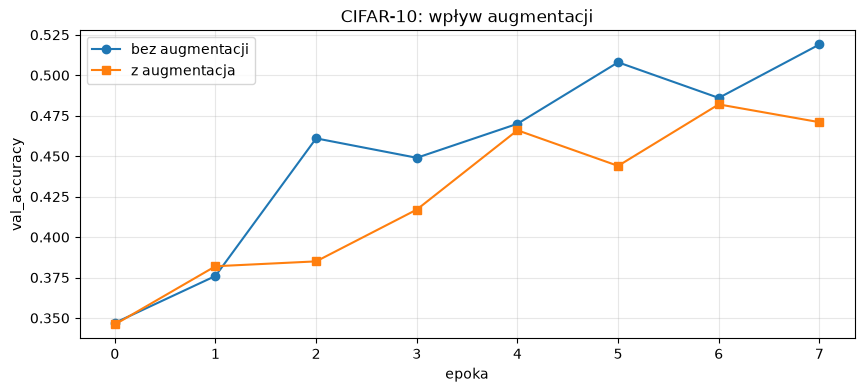

In [13]:
# Pobierz CIFAR-10 (mniejszy subset by zmiescic w czasie)
cifar = load_dataset("uoft-cs/cifar10")
def cifar_subset(n_train=5000, n_test=1000):
    tr_imgs = np.array([np.array(img) for img in cifar["train"]["img"][:n_train]], dtype=np.float32) / 255.0
    tr_labs = np.array(cifar["train"]["label"][:n_train])
    te_imgs = np.array([np.array(img) for img in cifar["test"]["img"][:n_test]], dtype=np.float32) / 255.0
    te_labs = np.array(cifar["test"]["label"][:n_test])
    return (tr_imgs, tr_labs), (te_imgs, te_labs)

(x_tr, y_tr), (x_te, y_te) = cifar_subset()
print(f"CIFAR train: {x_tr.shape}, test: {x_te.shape}")

def cifar_cnn():
    return keras.Sequential([
        layers.Input((32, 32, 3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

# Bez augmentacji
tf.random.set_seed(42)
m1 = cifar_cnn()
m1.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
h1 = m1.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=0)
print(f"Bez augmentacji: val_acc = {h1.history['val_accuracy'][-1]:.3f}")

# Z augmentacja jako warstwy modelu (nowoczesny sposob)
augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])
tf.random.set_seed(42)
m2 = keras.Sequential([augment, cifar_cnn()])
m2.compile("adam", "sparse_categorical_crossentropy", ["accuracy"])
h2 = m2.fit(x_tr, y_tr, epochs=8, batch_size=64, validation_data=(x_te, y_te), verbose=0)
print(f"Z augmentacja:    val_acc = {h2.history['val_accuracy'][-1]:.3f}")

# Wykres
plt.figure(figsize=(10, 4))
plt.plot(h1.history["val_accuracy"], "o-", label="bez augmentacji")
plt.plot(h2.history["val_accuracy"], "s-", label="z augmentacja")
plt.xlabel("epoka"); plt.ylabel("val_accuracy")
plt.title("CIFAR-10: wpływ augmentacji")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Zadanie 5.1 — Optymalna augmentacja dla Fashion-MNIST (mini grid search)

**Cel:** znajdź **dobrą kombinację augmentacji** dla Fashion-MNIST metodą grid search z cross-walidacją — **w czasie pozwalającym ukończyć zadanie na laptopie** (~15 min CPU).

**Wymagania:**

1. Bierzemy **4000 obrazów** z Fashion-MNIST (10 klas).
2. Mini grid (8 konfiguracji):
   - `rotation` ∈ {0.0, 0.15}
   - `zoom` ∈ {0.0, 0.15}
   - `flip` ∈ {None, "horizontal"}
3. **2-fold CV** (sklearn `KFold(n_splits=2)`).
4. **3 epoki** treningu CNN per fold (krótko, dla speedu).
5. Raportuj **średnie val_accuracy** dla każdej konfiguracji.
6. Wybierz top 3 konfiguracje, narysuj wykres słupkowy.
7. **Wniosek:** która augmentacja najbardziej pomogła? Czy flip poziomy zaszkodził w jakiejś klasie (sprawdź na confusion matrix dla flip=horizontal)?

**Szacowany czas:** 8 configs × 2 folds × 3 epoki × 2000 train images ≈ **15 min CPU**.

**Wskazówka:**
```python
from sklearn.model_selection import KFold
kf = KFold(n_splits=2, shuffle=True, random_state=42)
for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    aug = keras.Sequential([layers.RandomRotation(0.15), layers.RandomZoom(0.15)])
    model = keras.Sequential([aug, small_cnn((28,28,1), 10)])
    model.compile(...)
    model.fit(X[tr_idx], y[tr_idx], epochs=3, validation_data=(X[val_idx], y[val_idx]))
```

Liczba konfiguracji do testu: 8
rot=0.0  zoom=0.0  flip=None       | val_acc=0.7828
rot=0.0  zoom=0.0  flip=horizontal | val_acc=0.7760
rot=0.0  zoom=0.15 flip=None       | val_acc=0.7575
rot=0.0  zoom=0.15 flip=horizontal | val_acc=0.7485
rot=0.15 zoom=0.0  flip=None       | val_acc=0.6910
rot=0.15 zoom=0.0  flip=horizontal | val_acc=0.6612
rot=0.15 zoom=0.15 flip=None       | val_acc=0.6578
rot=0.15 zoom=0.15 flip=horizontal | val_acc=0.6465


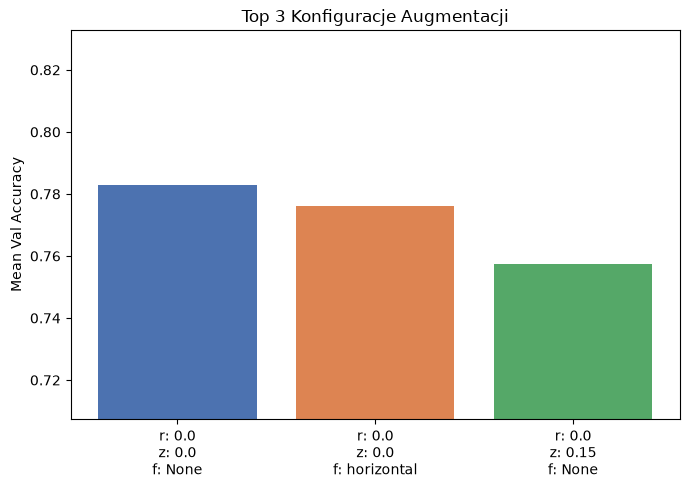


Confusion Matrix (Best Config):
[[142   0   1  17   2   1  36   0   1   0]
 [  0 189   0  12   0   0   2   0   0   0]
 [  1   0 123   3  57   0  30   0   0   0]
 [  2   2   0 166   7   0  13   0   0   0]
 [  0   0   9   5 190   0  14   0   1   0]
 [  0   0   0   0   0 176   0  17   0   2]
 [ 14   0  11   4  41   1 126   0   0   0]
 [  0   0   0   0   0   3   0 187   1   9]
 [  2   0   1   3   1   2  18   0 167   0]
 [  0   0   0   0   0   1   1   7   0 179]]


In [15]:
# Zadanie 5.1 -- mini grid search augmentacji + KFold (scaffold)
from sklearn.model_selection import KFold
import itertools

# Maly subset Fashion-MNIST (4000 obrazow) dla rozsadnego czasu treningu
N_FASHION = 4000
X_fmnist = x_tr_full[:N_FASHION]   # (N, 28, 28, 1) -- juz znormalizowane
y_fmnist = y_tr_full[:N_FASHION]

# Grid -- 8 konfiguracji
grid = list(itertools.product(
    [0.0, 0.15],          # rotation
    [0.0, 0.15],          # zoom
    [None, "horizontal"], # flip
))
print(f"Liczba konfiguracji do testu: {len(grid)}")

def build_aug_pipeline(rot: float, zoom: float, flip: str | None):
    """Buduje sekwencję warstw augmentacji wg konfiguracji."""
    layers_list = []
    if flip is not None:
        layers_list.append(layers.RandomFlip(flip))
    if rot > 0:
        layers_list.append(layers.RandomRotation(rot))
    if zoom > 0:
        layers_list.append(layers.RandomZoom(zoom))
    return keras.Sequential(layers_list) if layers_list else None

def small_fashion_cnn():
    """Mala CNN -- 28x28 grayscale, 10 klas."""
    return keras.Sequential([
        layers.Input((28, 28, 1)),
        layers.Conv2D(16, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])

kf = KFold(n_splits=2, shuffle=True, random_state=42)
results = {}

for rot, zoom, flip in grid:
    fold_accs = []
    for tr_idx, val_idx in kf.split(X_fmnist):
        aug = build_aug_pipeline(rot, zoom, flip)
        base = small_fashion_cnn()
        model = keras.Sequential([aug, base]) if aug else base
        
        model.compile(
            optimizer="adam", 
            loss="sparse_categorical_crossentropy", 
            metrics=["accuracy"]
        )
        
        h = model.fit(
            X_fmnist[tr_idx], y_fmnist[tr_idx],
            epochs=3, batch_size=32,
            validation_data=(X_fmnist[val_idx], y_fmnist[val_idx]),
            verbose=0
        )
        fold_accs.append(h.history["val_accuracy"][-1])
        
    mean_acc = float(np.mean(fold_accs))
    results[(rot, zoom, flip)] = mean_acc
    print(f"rot={rot:<4} zoom={zoom:<4} flip={str(flip):<10} | val_acc={mean_acc:.4f}")

sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
top_3 = sorted_results[:3]

labels = [f"r: {r}\nz: {z}\nf: {f}" for (r, z, f), acc in top_3]
accs = [acc for config, acc in top_3]

plt.figure(figsize=(7, 5))
plt.bar(labels, accs, color=['#4c72b0', '#dd8452', '#55a868'])
plt.ylim(min(accs) - 0.05, max(accs) + 0.05)
plt.title("Top 3 Konfiguracje Augmentacji")
plt.ylabel("Mean Val Accuracy")
plt.tight_layout()
plt.show()

best_config = top_3[0][0]
final_aug = build_aug_pipeline(*best_config)
final_base = small_fashion_cnn()
final_model = keras.Sequential([final_aug, final_base]) if final_aug else final_base

final_model.compile(
    optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)

final_model.fit(X_fmnist, y_fmnist, epochs=3, batch_size=32, verbose=0)

x_te_fashion = x_te_full[:2000]
y_te_fashion = y_te_full[:2000]

y_pred = np.argmax(final_model.predict(x_te_fashion, verbose=0), axis=1)

print("\nConfusion Matrix (Best Config):")
print(confusion_matrix(y_te_fashion, y_pred))

---

# Lab 6 — RNN i LSTM

## Teoria w trzech zdaniach

**Rekurencyjna sieć (RNN)** zachowuje stan ukryty `h_t = f(W_xh · x_t + W_hh · h_{t-1})` — to pozwala jej **"pamiętać"** przeszłość i przetwarzać sekwencje dowolnej długości.

**Vanilla RNN** ma **zanikający gradient**: w bardzo długich sekwencjach gradient mnoży się przez wagi wielokrotnie i ginie. **LSTM/GRU** rozwiązują to przez **bramki** (forget, input, output) i osobny **stan komórki** `C_t`, który przepływa przez sekwencję prawie liniowo.

**Pamiętaj:** dla NLP w 2026 standardem są **Transformery** (BERT, GPT). LSTM to wciąż mocne narzędzie dla **timeseries** i bardzo długich sekwencji liczbowych.

## Przykład rozwiązany: LSTM przewiduje sinusoidę z szumem

Train: (776, 30, 1), Test: (194, 30, 1)
Final val_loss: 0.0112


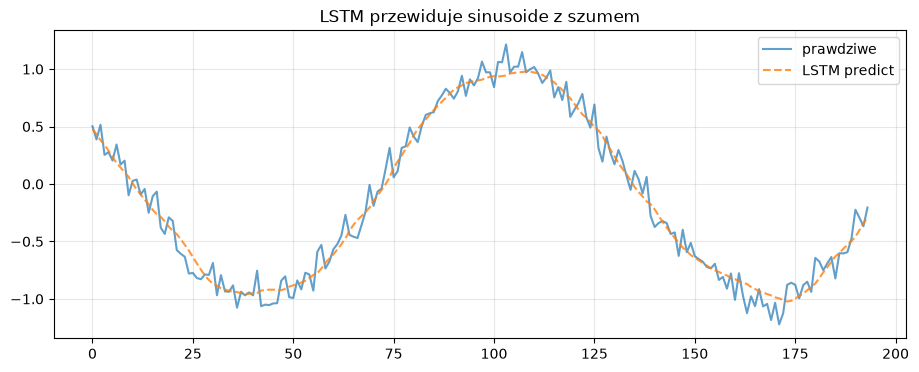

In [16]:
# Generuj synthetic timeseries: sinus + szum
np.random.seed(42)
T = 1000
t = np.linspace(0, 50, T)
y = np.sin(t) + 0.1 * np.random.randn(T)

# Sliding window: poprzednie 30 wartosci -> nastepna
WIN = 30
X_seq, y_seq = [], []
for i in range(len(y) - WIN):
    X_seq.append(y[i:i+WIN])
    y_seq.append(y[i+WIN])
X_seq = np.array(X_seq).reshape(-1, WIN, 1)
y_seq = np.array(y_seq)

# Train/test split (chronologiczny -- NIE shuffle!)
split = int(0.8 * len(X_seq))
X_tr, X_te = X_seq[:split], X_seq[split:]
y_tr, y_te = y_seq[:split], y_seq[split:]
print(f"Train: {X_tr.shape}, Test: {X_te.shape}")

tf.random.set_seed(42)
model_lstm = keras.Sequential([
    layers.Input((WIN, 1)),
    layers.LSTM(32),
    layers.Dense(1),
])
model_lstm.compile("adam", "mse")
hist = model_lstm.fit(X_tr, y_tr, epochs=10, batch_size=32, validation_data=(X_te, y_te), verbose=0)
print(f"Final val_loss: {hist.history['val_loss'][-1]:.4f}")

# Predykcja
y_pred = model_lstm.predict(X_te, verbose=0).ravel()
plt.figure(figsize=(11, 4))
plt.plot(y_te, label="prawdziwe", alpha=0.7)
plt.plot(y_pred, label="LSTM predict", alpha=0.8, linestyle="--")
plt.title("LSTM przewiduje sinusoide z szumem")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## Zadanie 6.1 — LSTM dla klasyfikacji emocji w tekście

**Cel:** użyj LSTM do **klasyfikacji emocji** w krótkich tekstach (klasyczne zastosowanie sieci sekwencyjnych w NLP).

**Wymagania:**

1. Pobierz dataset `dair-ai/emotion` z HF (`load_dataset("dair-ai/emotion")`). Ma 16k train + 2k test, 6 klas (sadness, joy, love, anger, fear, surprise).
2. **Tokenizacja:** użyj `keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)` i nauczyć ją na train.
3. **Architektura:** `Embedding(10000, 64) → LSTM(64) → Dropout(0.5) → Dense(6, softmax)`.
4. Trenuj 10 epok, batch_size=64.
5. Wykres: train/val accuracy + loss.
6. Confusion matrix na test set.
7. Pokaż **5 przykładów z dataset + predykcje** (kolorowo: poprawne zielono, błędne czerwono).
8. **Wniosek:** które emocje są najtrudniejsze do rozróżnienia? Dlaczego?

**Wskazówka — vectorize input:**
```python
vectorizer = keras.layers.TextVectorization(max_tokens=10000, output_sequence_length=50)
vectorizer.adapt(train_texts)  # uczy slownik
X_train_ids = vectorizer(train_texts).numpy()  # teksty -> sekwencje id tokenow
```

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from datasets import load_dataset
from sklearn.metrics import confusion_matrix

data_emo = load_dataset("dair-ai/emotion")
raw_train = list(data_emo["train"]["text"])
raw_test = list(data_emo["test"]["text"])
lbl_train = np.array(data_emo["train"]["label"])
lbl_test = np.array(data_emo["test"]["label"])

text_proc = layers.TextVectorization(max_tokens=10000, output_sequence_length=50)
text_proc.adapt(raw_train)

data_tr = text_proc(raw_train).numpy()
data_te = text_proc(raw_test).numpy()

nlp_model = keras.Sequential([
    layers.Embedding(input_dim=10000, output_dim=128),
    layers.SpatialDropout1D(0.3),
    layers.LSTM(128, return_sequences=False),
    layers.Dropout(0.4),
    layers.Dense(32, activation="relu"),
    layers.Dense(6, activation="softmax")
])

nlp_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

run_hist = nlp_model.fit(
    data_tr, lbl_train,
    epochs=10,
    batch_size=128,
    validation_data=(data_te, lbl_test),
    verbose=1
)

fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(14, 5))
ax_acc.plot(run_hist.history["accuracy"], label="Treningowa")
ax_acc.plot(run_hist.history["val_accuracy"], label="Walidacyjna")
ax_acc.set_title("Dokładność modelu")
ax_acc.legend()

ax_loss.plot(run_hist.history["loss"], label="Treningowa")
ax_loss.plot(run_hist.history["val_loss"], label="Walidacyjna")
ax_loss.set_title("Funkcja kosztu")
ax_loss.legend()
plt.show()

y_scores = nlp_model.predict(data_te)
y_predictions = np.argmax(y_scores, axis=1)

print("\nMacierz błędów:")
print(confusion_matrix(lbl_test, y_predictions))

target_tags = ["sadness", "joy", "love", "anger", "fear", "surprise"]
print("\nTestowanie na losowych próbkach:")

random_picks = np.random.RandomState(42).choice(len(raw_test), 5, replace=False)
for i in random_picks:
    t_val = target_tags[lbl_test[i]]
    p_val = target_tags[y_predictions[i]]
    indicator = "OK" if t_val == p_val else "BŁĄD"
    
    print(f"[{indicator}] Wejście: {raw_test[i]}")
    print(f"    Etykieta: {t_val}, Model: {p_val}")

AttributeError: 'Column' object has no attribute 'to_list'

---

# Sekcja kontrolna — co umiesz po tym zestawie

Po ukończeniu wszystkich 6 zadań powinieneś **bez przygotowania** odpowiedzieć na:

1. **Perceptron:** dlaczego nie nauczy się XOR? Co geometrycznie znaczy *liniowa separowalność*?
2. **MLP:** ile warstw ukrytych potrzeba do XOR i dlaczego? Co znaczy uniwersalny approximator?
3. **Backprop:** który gradient pierwszy się liczy — wejście czy wyjście? Dlaczego mówimy "backward"?
4. **CNN:** co znaczy "convolutional" — co rozróżnia ten typ warstwy od Dense?
5. **Augmentacja:** dlaczego nigdy nie augmentujemy zbioru testowego?
6. **LSTM:** jaką informację niesie stan ukryty `h_t`, a jaką stan komórki `C_t`? Dlaczego dwa?

## Co dalej?

- **Transfer learning:** pretrained ResNet/EfficientNet → twój problem. Często mniej kodu + lepsze wyniki niż trening od zera.
- **Transformery:** [HuggingFace course](https://huggingface.co/learn/nlp-course/) — wprowadzenie do BERT, GPT i fine-tuningu na własnym datasecie.
- **Praktyka:** Kaggle competitions to najszybsza droga do mistrzostwa. Zacznij od kategorii "Getting Started".
- **Theory deep dive:** ["Deep Learning" Goodfellow et al.](https://www.deeplearningbook.org/) — darmowa, kompletna, do trzymania pod ręką.

In [ ]:
# Sprzatanie / podsumowanie
print(f"Workspace: {WORKDIR.resolve()}")
print("Zestaw zaliczeniowy ukonczony. Powodzenia w karierze!")